In [17]:
import numpy as np
import pandas as pd
df = pd.read_csv("../data/donnees_employes.csv")

In [18]:
df.head() # display the first 5 rows of the dataframe

,ID_Emp,Dep_name,Age,Gender,Edu_level,Exp_years,Annual_income,Week_WoekHours,Performance_Score,Work_satisfaction,Home_distance_km,Leaves_days,Project_finished,Training_hours,Bonus_year,Hiring_Date,Seniority_years,Wage_hour
0,1,Marketing,43,H,Master,8,114178,36.6,2,4,85,23,10,43,1667,2022-10-05,2.2,59.99
1,2,Finance,42,F,Licence,24,41094,34.9,5,5,16,17,12,8,909,2017-03-05,7.8,22.64
2,3,Ventes,27,H,Master,28,117959,37.8,2,1,9,20,1,66,8467,2021-10-15,3.1,60.01
3,4,Finance,27,F,Bac,24,63418,39.4,3,1,13,26,7,53,9083,2019-03-04,5.8,30.95
4,5,Finance,25,F,Bac,27,35741,43.3,2,2,28,21,17,25,8204,2017-01-30,7.8,15.87


In [19]:
df.info() # display dT types 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID_Emp             1000 non-null   int64  
 1   Dep_name           1000 non-null   object 
 2   Age                1000 non-null   int64  
 3   Gender             1000 non-null   object 
 4   Edu_level          1000 non-null   object 
 5   Exp_years          1000 non-null   int64  
 6   Annual_income      1000 non-null   int64  
 7   Week_WoekHours     1000 non-null   float64
 8   Performance_Score  1000 non-null   int64  
 9   Work_satisfaction  1000 non-null   int64  
 10  Home_distance_km   1000 non-null   int64  
 11  Leaves_days        1000 non-null   int64  
 12  Project_finished   1000 non-null   int64  
 13  Training_hours     1000 non-null   int64  
 14  Bonus_year         1000 non-null   int64  
 15  Hiring_Date        1000 non-null   object 
 16  Seniority_years    1000 n

# Nettoyage des données

#### Vérification des valeurs manquantes

In [20]:
print(df.isnull().sum())

ID_Emp               0
Dep_name             0
Age                  0
Gender               0
Edu_level            0
Exp_years            0
Annual_income        0
Week_WoekHours       0
Performance_Score    0
Work_satisfaction    0
Home_distance_km     0
Leaves_days          0
Project_finished     0
Training_hours       0
Bonus_year           0
Hiring_Date          0
Seniority_years      0
Wage_hour            0
dtype: int64


In [21]:
df.duplicated().sum()

np.int64(0)

#### suppression le column ID_Employe

In [22]:
df.drop(columns=["ID_Emp"], inplace=True)
df.drop(columns=["Hiring_Date"], inplace=True)

In [23]:
from sklearn.preprocessing import StandardScaler
def normalize_and_remove_outliers(df, columns, z_threshold=3):
    # Create a copy of the DataFrame to avoid modifying the original
    df_cleaned = df.copy()

    # Initialize StandardScaler
    scaler = StandardScaler()

    # Normalize the numerical columns
    normalized_data = scaler.fit_transform(df[columns])
    normalized_df = pd.DataFrame(normalized_data, columns=columns, index=df.index)

    # Identify outliers (where absolute Z-score > threshold)
    outlier_mask = (normalized_df.abs() > z_threshold).any(axis=1)

    # Remove outliers from the original DataFrame
    df_cleaned = df_cleaned.loc[~outlier_mask]

    # Replace original numerical columns with normalized values
    df_cleaned[columns] = normalized_df.loc[~outlier_mask]

    return df_cleaned

In [24]:

# Apply the function to your DataFrame
numerical_cols = df.select_dtypes('number').columns
df = normalize_and_remove_outliers(df, numerical_cols, z_threshold=3)

In [25]:

df.shape

(997, 16)

In [26]:
#outliers.any(axis=1)

### Visualisation des données

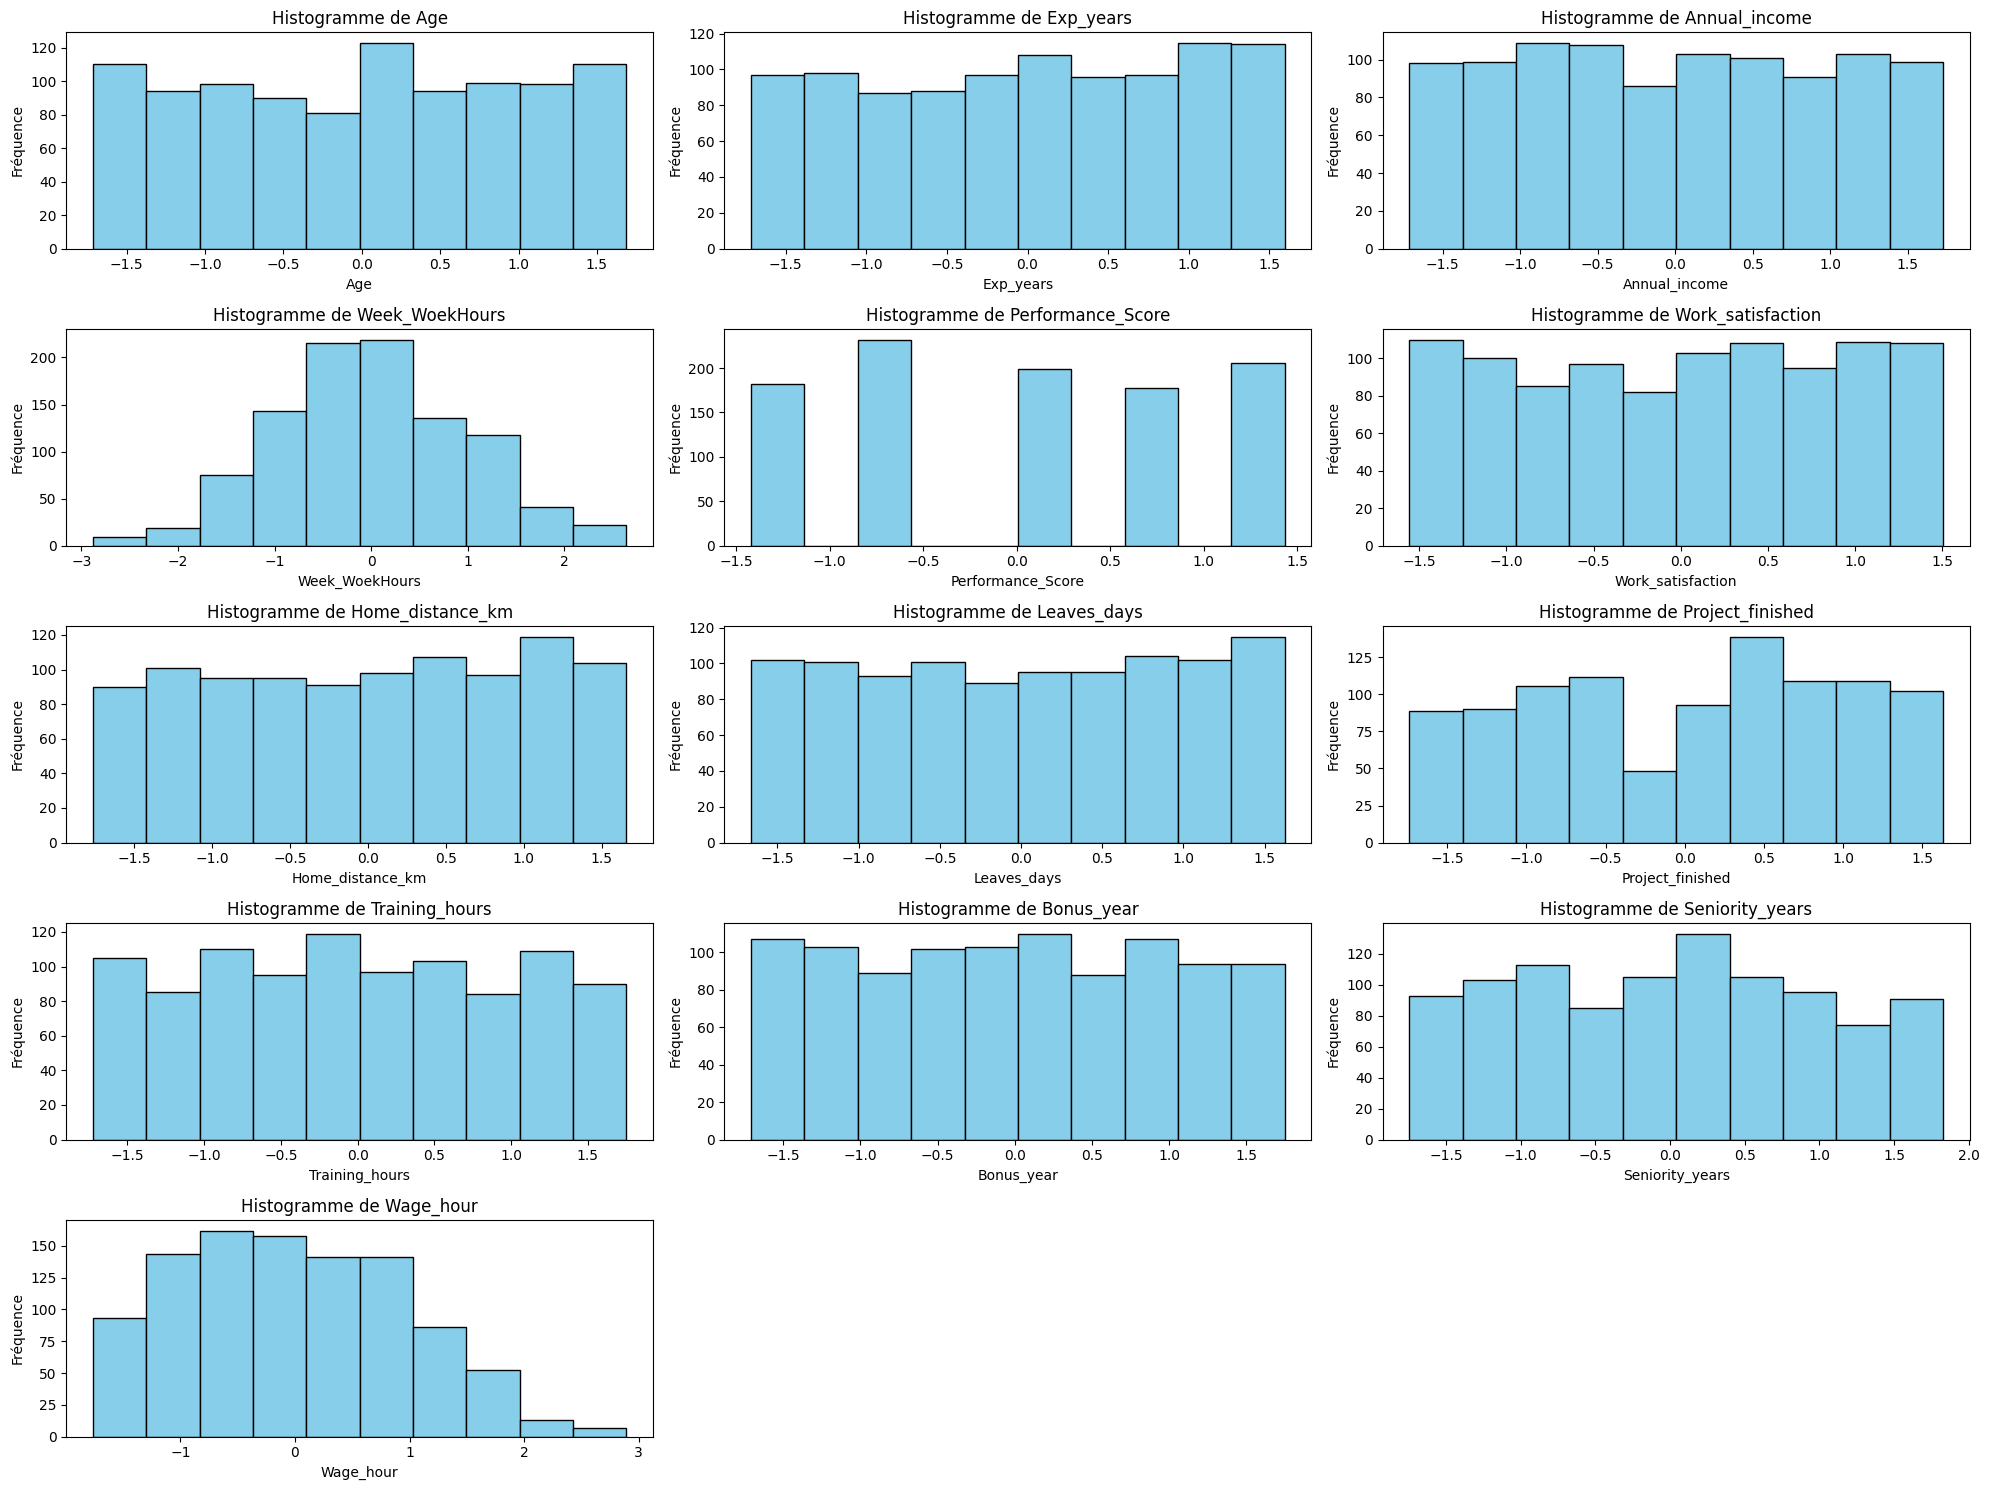

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20, 15))

# Adjust the number of rows and columns to fit all numeric columns
num_columns = len(numerical_cols)
num_rows = (num_columns + 2) // 3  # Calculate the number of rows needed

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(num_rows, 3, i)  # Adjust the grid size
    plt.hist(df[col], bins=10, color='skyblue', edgecolor='black')
    plt.title(f'Histogramme de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')

# Ajuster l'espacement entre les sous-graphes
plt.tight_layout()

# Afficher les histogrammes
plt.show()

# data preparation

In [28]:
df.head()

,Dep_name,Age,Gender,Edu_level,Exp_years,Annual_income,Week_WoekHours,Performance_Score,Work_satisfaction,Home_distance_km,Leaves_days,Project_finished,Training_hours,Bonus_year,Seniority_years,Wage_hour
0,Marketing,-0.013290,H,Master,-0.801165,1.505881,-0.268905,-0.706611,-0.536256,1.169565,0.944398,-0.053912,-0.214742,-1.132593,-1.229306,1.476798
1,Finance,-0.094327,F,Licence,1.024072,-1.300065,-0.608080,1.432474,-0.196208,-1.240037,0.264404,0.320479,-1.444250,-1.395137,0.993168,-1.103754
2,Ventes,-1.309880,H,Master,1.480381,1.651047,-0.029488,-0.706611,-1.556400,-1.484490,0.604401,-1.738672,0.593220,1.222684,-0.872122,1.478180
3,Finance,-1.309880,F,Bac,1.024072,-0.442970,0.289735,0.006417,-1.556400,-1.344803,1.284395,-0.615499,0.136546,1.436045,0.199427,-0.529607
4,Finance,-1.471954,F,Bac,1.366304,-1.505585,1.067841,-0.706611,-1.216352,-0.820976,0.717733,1.256456,-0.847060,1.131590,0.993168,-1.571501


#### Encodage des variables catégorielles ['Nom_Departement', 'Genre', "Niveau_Education"]

In [29]:
cat_features = df.select_dtypes(include=['object']).columns
# Convert categorical features to numerical using one-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=True, dtype=int)
# Display the first few rows of the encoded DataFrame
df_encoded.head()

,Age,Exp_years,Annual_income,Week_WoekHours,Performance_Score,Work_satisfaction,Home_distance_km,Leaves_days,Project_finished,Training_hours,...,Dep_name_IT,Dep_name_Marketing,Dep_name_R&D,Dep_name_RH,Dep_name_Ventes,Gender_F,Gender_H,Edu_level_Doctorat,Edu_level_Licence,Edu_level_Master
0,-0.013290,-0.801165,1.505881,-0.268905,-0.706611,-0.536256,1.169565,0.944398,-0.053912,-0.214742,...,0,1,0,0,0,0,1,0,0,1
1,-0.094327,1.024072,-1.300065,-0.608080,1.432474,-0.196208,-1.240037,0.264404,0.320479,-1.444250,...,0,0,0,0,0,1,0,0,1,0
2,-1.309880,1.480381,1.651047,-0.029488,-0.706611,-1.556400,-1.484490,0.604401,-1.738672,0.593220,...,0,0,0,0,1,0,1,0,0,1
3,-1.309880,1.024072,-0.442970,0.289735,0.006417,-1.556400,-1.344803,1.284395,-0.615499,0.136546,...,0,0,0,0,0,1,0,0,0,0
4,-1.471954,1.366304,-1.505585,1.067841,-0.706611,-1.216352,-0.820976,0.717733,1.256456,-0.847060,...,0,0,0,0,0,1,0,0,0,0


#### Séparation des features et de la variable cible

In [31]:
X = df_encoded.drop("Annual_income", axis=1) #.to_numpy()
y = df_encoded["Annual_income"]



#### Normalisation des données [X_train, X_test, y_train, y_test]

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
X_train.shape

(797, 22)

In [34]:
# # Normalisation des données
# scaler = StandardScaler()

# # Normalisation de X_train et X_test
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
# y_train = scaler.fit_transform(y_train.values.reshape(-1, 1))
# y_test = scaler.transform(y_test.values.reshape(-1, 1))

#  ***deep learning***

#### Création du modèle de deep learning

In [36]:
pip install tensorflow keras 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 21.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 7.0 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 23.5 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 35.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 42.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 41.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4
Note: you may need to restart the kernel to use updated packages.


In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1

2025-04-02 00:56:59.100708: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-02 00:56:59.381018: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-02 00:56:59.519051: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743555419.724217    6655 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743555419.792681    6655 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743555420.066736    6655 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [38]:
# Define the Keras Sequential model
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),  # Explicit input layer
    layers.Dense(64, activation="relu", kernel_regularizer=l1(0.01)),
    layers.Dense(32, activation="relu", kernel_regularizer=l1(0.01)),
    layers.Dense(16, activation="relu", kernel_regularizer=l1(0.01)),
    layers.Dense(1)
])

2025-04-02 00:57:12.456294: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

#### Compilation du modèle

In [40]:
#from tensorflow.keras.optimizers import Adam   # SGD # RMSprop # Adagrad # Adam
#algor = Adam(learning_rate=0.001)

model.compile(optimizer="Adam", loss="mse", metrics=["mae"]) # mse: Mean Squared Error, mae: Mean Absolute Error

#### Entraînement du modèle

In [41]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor = "val_loss", patience = 50, restore_best_weights = True)


history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.4973 - mae: 0.8940 - val_loss: 6.2464 - val_mae: 0.9036
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0583 - mae: 0.8230 - val_loss: 5.8865 - val_mae: 0.8464
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6492 - mae: 0.7298 - val_loss: 5.5194 - val_mae: 0.7743
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.3293 - mae: 0.6872 - val_loss: 5.1046 - val_mae: 0.6570
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.9336 - mae: 0.5769 - val_loss: 4.6692 - val_mae: 0.5030
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.5678 - mae: 0.4725 - val_loss: 4.2818 - val_mae: 0.3563
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.1775 - mae: 0.3024 - val_loss: 3.9850 - val_mae: 0.2678
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9112 - mae: 0.2421 - val_loss: 3.7301 - val_mae: 0.2245
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.6607 - mae: 0

#### Évaluation du modèle

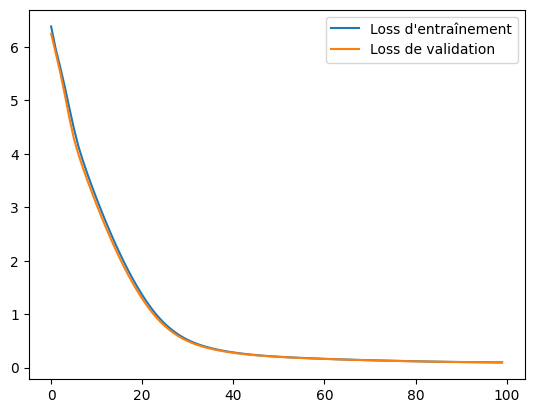

In [42]:
plt.plot(history.history['loss'], label="Loss d'entraînement")
plt.plot(history.history['val_loss'], label="Loss de validation")
plt.legend()
plt.show()

#### Évaluation sur les données de test

In [43]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Erreur quadratique moyenne (MSE) : {loss}")
print(f"Erreur absolue moyenne (MAE) : {mae}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0964 - mae: 0.0562 
Erreur quadratique moyenne (MSE) : 0.096353679895401
Erreur absolue moyenne (MAE) : 0.05574284866452217


### utilisation de méthode predict

In [44]:
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


# Visualisation des résultats

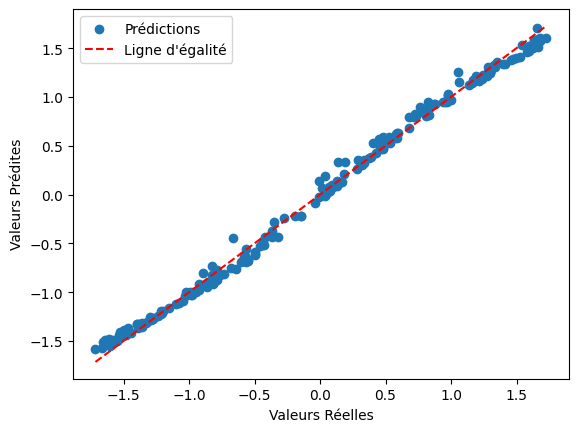

In [45]:
plt.scatter(y_test, y_pred, label='Prédictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ligne d\'égalité')
plt.xlabel('Valeurs Réelles')
plt.ylabel('Valeurs Prédites')
plt.legend()
plt.show()